In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                              precision_recall_curve, PrecisionRecallDisplay, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("../data/cleaned/fraud_features.csv")
df["Recent_Address_Change"] = df["AddressChange_Claim"].isin(["under 6 months", "2 to 3 years"]).astype(int)
print(df.shape)

(15419, 51)


In [2]:
feature_cols_num = ["Age_Clean", "VehiclePrice_ord", "PastNumberOfClaims_ord", "AgeOfVehicle_ord",
                     "NumberOfSuppliments_ord", "Days_Policy_Accident_ord", "Days_Policy_Claim_ord",
                     "Claim_Delay_Months", "DriverRating", "Deductible", "Year"]
feature_cols_cat = ["PolicyType", "Fault", "AccidentArea", "VehicleCategory", "Sex", "MaritalStatus",
                     "AgentType", "BasePolicy"]
feature_cols_bin = ["Police_Report", "Witness", "Policyholder_At_Fault", "Agent_External",
                     "Weekend_Accident", "Weekend_Claim", "Age_Missing", "Recent_Address_Change"]

excluded = {
    "PolicyNumber": "unique ID, no predictive meaning, risk of memorization",
    "AgeOfPolicyHolder_ord": "correlates 0.96 with Age_Clean — redundant, would split importance artificially",
    "RepNumber": "internal agent code, not a claim risk factor a model should key on operationally",
}
print("Excluded:", excluded)

feature_cols = feature_cols_num + feature_cols_cat + feature_cols_bin
X = df[feature_cols].copy()
y = df["FraudFound_P"].copy()

print(X.shape, y.shape)
print(y.value_counts(normalize=True).round(4))

Excluded: {'PolicyNumber': 'unique ID, no predictive meaning, risk of memorization', 'AgeOfPolicyHolder_ord': 'correlates 0.96 with Age_Clean — redundant, would split importance artificially', 'RepNumber': 'internal agent code, not a claim risk factor a model should key on operationally'}
(15419, 27) (15419,)
FraudFound_P
0    0.9401
1    0.0599
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "Fraud rate:", y_train.mean().round(4))
print("Test:", X_test.shape, "Fraud rate:", y_test.mean().round(4))

Train: (12335, 27) Fraud rate: 0.0598
Test: (3084, 27) Fraud rate: 0.06


In [9]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), feature_cols_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ("bin", "passthrough", feature_cols_bin),
])

In [10]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print(f"Dummy accuracy (always predict 'no fraud'): {dummy.score(X_test, y_test):.3f}")
print(f"Dummy recall on fraud (always misses every case): 0.000")

Dummy accuracy (always predict 'no fraud'): 0.940
Dummy recall on fraud (always misses every case): 0.000


In [11]:
logreg = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])
logreg.fit(X_train, y_train)

logreg_proba = logreg.predict_proba(X_test)[:, 1]
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, logreg_proba):.3f}")
print(f"Logistic Regression PR-AUC (avg precision): {average_precision_score(y_test, logreg_proba):.3f}")
print(classification_report(y_test, logreg.predict(X_test)))

Logistic Regression ROC-AUC: 0.819
Logistic Regression PR-AUC (avg precision): 0.167
              precision    recall  f1-score   support

           0       1.00      0.58      0.73      2899
           1       0.13      0.96      0.22       185

    accuracy                           0.60      3084
   macro avg       0.56      0.77      0.48      3084
weighted avg       0.94      0.60      0.70      3084



In [12]:
rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                     class_weight="balanced", random_state=42, n_jobs=-1))
])
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")
print(f"Random Forest PR-AUC (avg precision): {average_precision_score(y_test, rf_proba):.3f}")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest ROC-AUC: 0.820
Random Forest PR-AUC (avg precision): 0.207
              precision    recall  f1-score   support

           0       0.99      0.58      0.74      2899
           1       0.13      0.95      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.77      0.48      3084
weighted avg       0.94      0.61      0.70      3084



In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="average_precision")
print(f"5-fold CV PR-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-fold CV PR-AUC: 0.193 ± 0.013


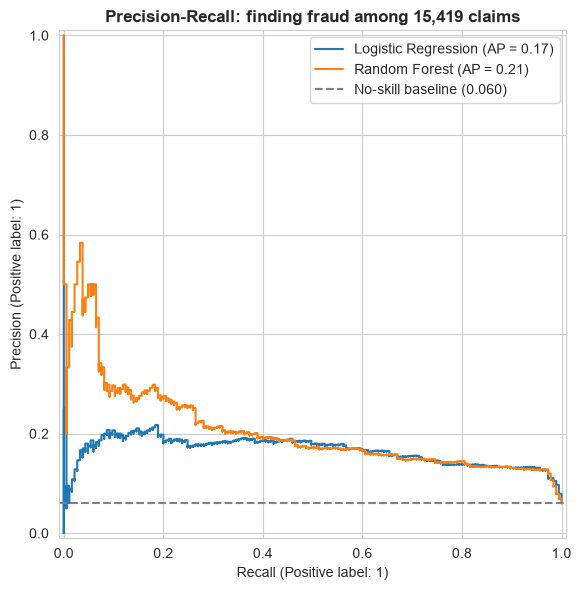

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test, logreg_proba, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"No-skill baseline ({y_test.mean():.3f})")
ax.set_title("Precision-Recall: finding fraud among 15,419 claims", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../images/07_precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

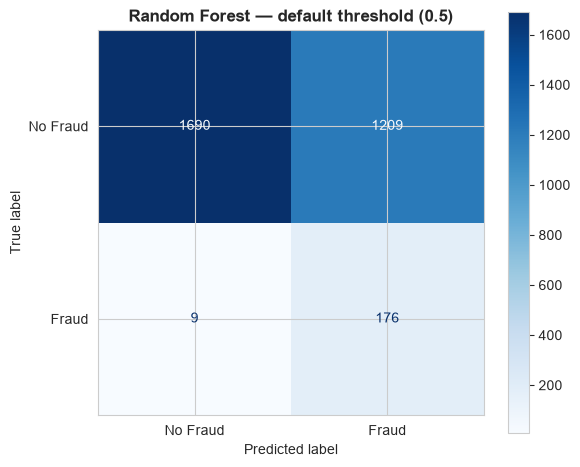

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["No Fraud", "Fraud"]).plot(ax=ax, cmap="Blues")
ax.set_title("Random Forest — default threshold (0.5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/08_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_proba)

# How many fraud cases would we catch by flagging the top 10% riskiest claims?
top_10pct_cutoff = np.percentile(rf_proba, 90)
flagged = rf_proba >= top_10pct_cutoff
print(f"Claims flagged (top 10% riskiest): {flagged.sum()} out of {len(y_test)}")
print(f"Actual fraud among flagged: {y_test[flagged].sum()} out of {y_test.sum()} total fraud cases")
print(f"Fraud capture rate (recall) at top 10%: {y_test[flagged].sum() / y_test.sum():.1%}")
print(f"Precision among flagged: {y_test[flagged].mean():.1%}")

Claims flagged (top 10% riskiest): 309 out of 3084
Actual fraud among flagged: 63 out of 185 total fraud cases
Fraud capture rate (recall) at top 10%: 34.1%
Precision among flagged: 20.4%


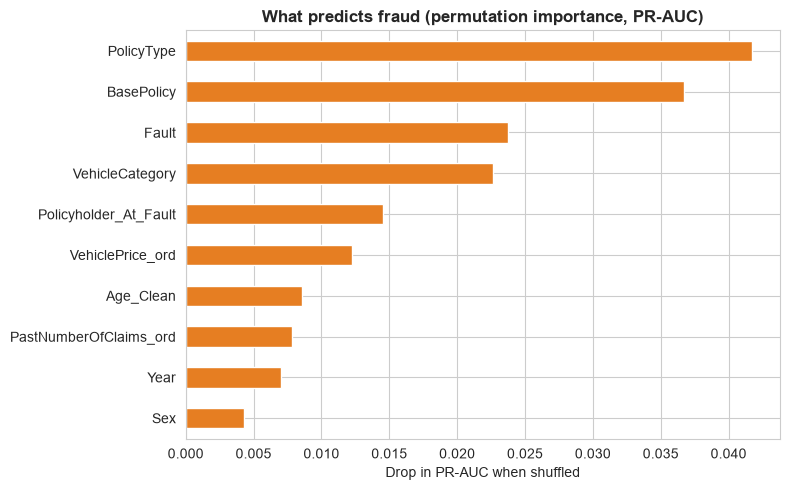

PolicyType                0.041700
BasePolicy                0.036728
Fault                     0.023758
VehicleCategory           0.022635
Policyholder_At_Fault     0.014508
VehiclePrice_ord          0.012239
Age_Clean                 0.008583
PastNumberOfClaims_ord    0.007808
Year                      0.007033
Sex                       0.004311
dtype: float64


In [17]:
result = permutation_importance(rf, X_test, y_test, n_repeats=15, scoring="average_precision",
                                  random_state=42, n_jobs=-1)
importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(10).plot(kind="barh", ax=ax, color="#E67E22")
ax.invert_yaxis()
ax.set_title("What predicts fraud (permutation importance, PR-AUC)", fontsize=12, fontweight="bold")
ax.set_xlabel("Drop in PR-AUC when shuffled")
plt.tight_layout()
plt.savefig("../images/09_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(importances.head(10))

## Model Limitations
This model uses only pre-decision claim and policy features, deliberately excluding
PolicyNumber (an ID) and the redundant AgeOfPolicyHolder_ord (correlated 0.96 with Age_Clean).
Given the 5.99% fraud rate, accuracy is not a meaningful metric — a model predicting "no fraud"
for every claim scores ~94% accuracy while catching zero fraud. PR-AUC and the top-10%
capture rate are the metrics that matter for this use case: ranking claims for limited
investigator capacity, not making a hard yes/no call on every claim.

In [18]:
print({"logreg_prauc": average_precision_score(y_test, logreg_proba),
       "rf_prauc": average_precision_score(y_test, rf_proba),
       "cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()})

{'logreg_prauc': 0.16660277084819952, 'rf_prauc': 0.20722821355862067, 'cv_mean': np.float64(0.1925652061902558), 'cv_std': np.float64(0.013367699776290409)}
